In [1]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:42<00:00, 15.2MB/s]



In [2]:
!unzip -q chest-xray-pneumonia.zip -d ./data
print("Unzip complete ✓")

Unzip complete ✓


In [3]:
import os
import shutil

src_base = "./data/chest_xray"
dst_base = "./data"

for folder in ["train", "test", "val"]:
    src = os.path.join(src_base, folder)
    dst = os.path.join(dst_base, folder)

    if os.path.exists(src) and not os.path.exists(dst):
        shutil.move(src, dst)

shutil.rmtree("./data/chest_xray", ignore_errors=True)
shutil.rmtree("./data/__MACOSX", ignore_errors=True)

print("Clean dataset structure ready")
!ls ./data

Clean dataset structure ready
test  train  val


In [4]:
!ls ./data/

test  train  val


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32

EPOCHS_WARM = 10
EPOCHS_FINE = 10

LR_WARM = 1e-4
LR_FINE = 1e-5

DATA_DIR = "./data"
MODEL_PATH = "best_mobilenetv2_pneumonia.keras"

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Configuration done")

Configuration done


In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("Image preprocessing ready")

Image preprocessing ready


In [8]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class mapping:", train_gen.class_indices)
print("Train samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)
print("Test samples:", test_gen.samples)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 5216
Validation samples: 16
Test samples: 624


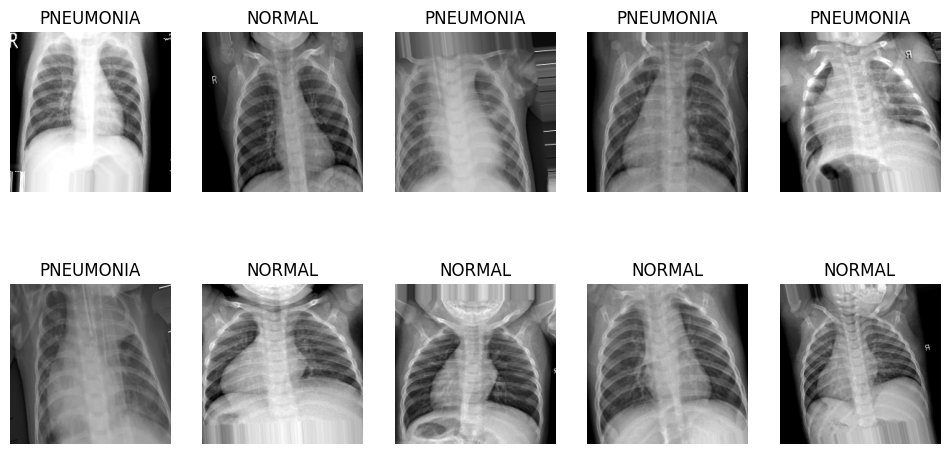

In [9]:
images, labels = next(train_gen)

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    img = images[i]
    img = (img + 1) / 2

    plt.imshow(img)
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis("off")

plt.show()

In [10]:
y_train = train_gen.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [11]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=LR_WARM),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled")

Model compiled


In [13]:
callbacks_warm = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [14]:
history_warm = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_WARM,
    class_weight=class_weights,
    callbacks=callbacks_warm
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.7302 - auc: 0.7668 - loss: 0.5992 - recall: 0.7639
Epoch 1: val_loss improved from None to 0.31105, saving model to best_mobilenetv2_pneumonia.keras

Epoch 1: finished saving model to best_mobilenetv2_pneumonia.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 793ms/step - accuracy: 0.8066 - auc: 0.8944 - loss: 0.4124 - recall: 0.8062 - val_accuracy: 0.7500 - val_auc: 0.9375 - val_loss: 0.3110 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.8948 - auc: 0.9640 - loss: 0.2408 - recall: 0.8804
Epoch 2: val_loss improved from 0.31105 to 0.26324, saving model to best_mobilenetv2_pneumonia.keras

Epoch 2: finished saving model to best_mobilenetv2_pneumonia.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 693ms/step - accuracy: 0.9034 - auc: 0.9679 - loss: 0.2247 - recall: 0.8924 - val_accuracy: 0.8750 - val_auc: 0.9375 - val_loss: 0.2632 - val_recall: 0.8750 - learning_rate: 

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Last 30 layers are trainable")

Last 30 layers are trainable


In [16]:
model.compile(
    optimizer=Adam(learning_rate=LR_FINE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Recall(name="recall")
    ]
)

print("Model recompiled for fine tuning")

Model recompiled for fine tuning


In [17]:
callbacks_fine = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

In [18]:
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    class_weight=class_weights,
    callbacks=callbacks_fine
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.8928 - auc: 0.9490 - loss: 0.3324 - recall: 0.9267
Epoch 1: val_loss improved from None to 0.95229, saving model to best_mobilenetv2_pneumonia.keras

Epoch 1: finished saving model to best_mobilenetv2_pneumonia.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 728ms/step - accuracy: 0.8999 - auc: 0.9593 - loss: 0.2679 - recall: 0.9125 - val_accuracy: 0.6875 - val_auc: 0.9531 - val_loss: 0.9523 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9219 - auc: 0.9792 - loss: 0.1812 - recall: 0.9115
Epoch 2: val_loss did not improve from 0.95229
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 666ms/step - accuracy: 0.9231 - auc: 0.9784 - loss: 0.1860 - recall: 0.9172 - val_accuracy: 0.6250 - val_auc: 0.8984 - val_loss: 1.2879 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.9190 - auc: 0.9777 - loss: 0.1906 - recall:

In [19]:
model = keras.models.load_model(MODEL_PATH)

print("Best model loaded")

Best model loaded


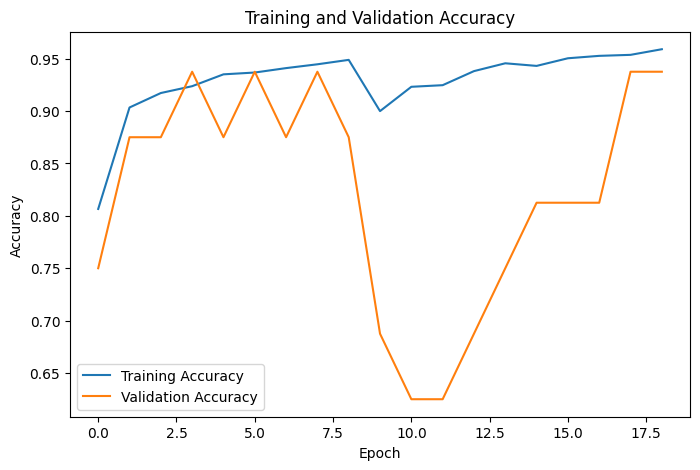

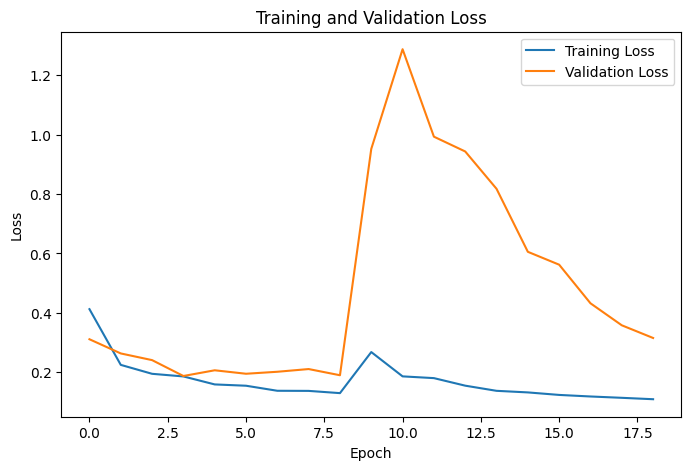

In [20]:
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

train_acc = combine_history(history_warm, history_fine, "accuracy")
val_acc = combine_history(history_warm, history_fine, "val_accuracy")

train_loss = combine_history(history_warm, history_fine, "loss")
val_loss = combine_history(history_warm, history_fine, "val_loss")

plt.figure(figsize=(8, 5))
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [21]:
test_gen.reset()

y_prob = model.predict(test_gen).ravel()
y_true = test_gen.classes

y_pred = (y_prob >= 0.5).astype(int)

print("Prediction completed")

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 462ms/step
Prediction completed


In [22]:
accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print("Accuracy :", accuracy)
print("Recall   :", recall)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8974358974358975
Recall   : 0.9794871794871794
ROC-AUC  : 0.9738384834538681


Confusion Matrix:
[[178  56]
 [  8 382]]


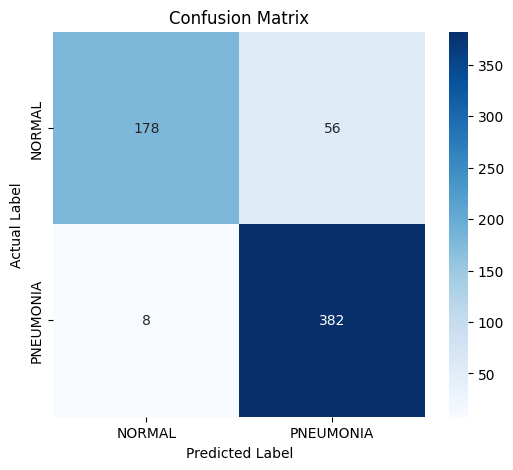

In [23]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [24]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.96      0.76      0.85       234
   PNEUMONIA       0.87      0.98      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.87      0.89       624
weighted avg       0.90      0.90      0.89       624



In [25]:
model.save("final_mobilenetv2_pneumonia_model.keras")

print("Final model saved")

Final model saved
